## Test EfficientNetV2M

In [1]:
import pathlib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATA_DIR = pathlib.Path("../../datasets/livrable1")
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 8
SEED = 123

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    validation_split=0.2,
    subset="both",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)

preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda images, labels: (preprocess_input(tf.cast(images, tf.float32)), labels),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

val_ds = val_ds.map(
    lambda images, labels: (preprocess_input(tf.cast(images, tf.float32)), labels),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

base_model = tf.keras.applications.EfficientNetV2M(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

for images, labels in train_ds.take(1):
    predictions = model(images)
    print("classes:", class_names)
    print("batch:", images.shape, labels.shape)
    print("predictions:", predictions.shape)

model.summary()

I0000 00:00:1780561341.859019  160243 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780561341.896529  160243 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780561343.158490  160243 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 41398 files belonging to 5 classes.
Using 33119 files for training.
Using 8279 files for validation.


W0000 00:00:1780561344.440813  160243 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
W0000 00:00:1780561348.422310  160472 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


classes: ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
batch: (8, 224, 224, 3) (8,)
predictions: (8, 5)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,156,793 (202.78 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

In [ ]:
EPOCHS_HEAD = 3
EPOCHS_FINE_TUNE = 2
FINE_TUNE_AT = len(base_model.layers) - 30

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
)

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers[FINE_TUNE_AT:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD + EPOCHS_FINE_TUNE,
    initial_epoch=history_head.epoch[-1] + 1,
    callbacks=callbacks,
)

history = history_head
history_fine_tune

Found 41398 files belonging to 5 classes.
Using 8279 files for validation.
Exemples de prédictions sur le jeu de validation :
- vrai: Text | prédit: Sketch | confiance: 0.244
- vrai: Schematics | prédit: Schematics | confiance: 0.292
- vrai: Text | prédit: Text | confiance: 0.232
- vrai: Painting | prédit: Schematics | confiance: 0.302
- vrai: Text | prédit: Text | confiance: 0.268


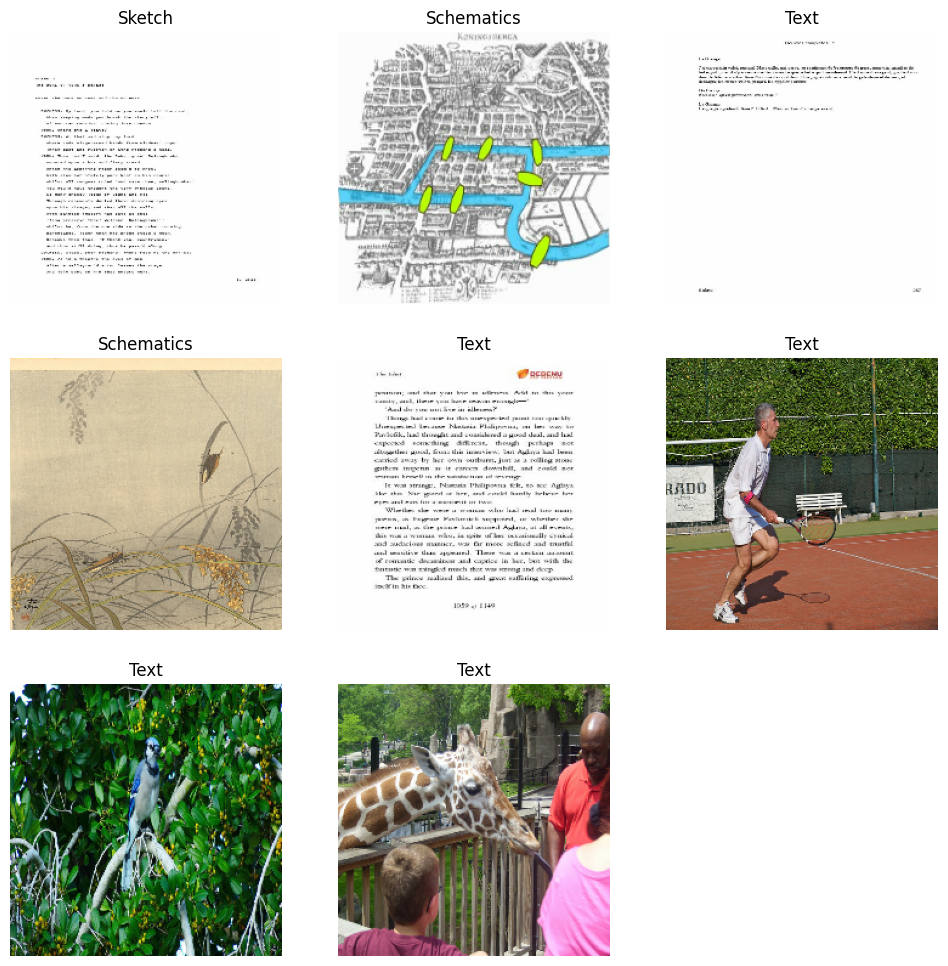

In [6]:
import matplotlib.pyplot as plt

raw_display_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
)

for raw_images_batch, labels_batch in raw_display_ds.take(1):
    processed_images_batch = preprocess_input(tf.cast(raw_images_batch, tf.float32))
    scores = model.predict(processed_images_batch, verbose=0)
    predicted_indices = tf.argmax(scores, axis=1)

    print("Exemples de prédictions sur le jeu de validation :")
    for index in range(min(5, raw_images_batch.shape[0])):
        true_label = class_names[int(labels_batch[index])]
        predicted_label = class_names[int(predicted_indices[index])]
        confidence = float(tf.reduce_max(scores[index]))
        print(f"- vrai: {true_label} | prédit: {predicted_label} | confiance: {confidence:.3f}")

    plt.figure(figsize=(12, 12))
    for index in range(min(9, raw_images_batch.shape[0])):
        ax = plt.subplot(3, 3, index + 1)
        plt.imshow(tf.cast(raw_images_batch[index], tf.uint8))
        plt.title(f"{class_names[int(predicted_indices[index])]}")
        plt.axis("off")

Nombre d'images dans datasets/final : 11
Prédictions sur datasets/final :
- image: 1.png | prédit: Text | confiance: 0.253
- image: 11.jpg | prédit: Text | confiance: 0.333
- image: 12.jpg | prédit: Sketch | confiance: 0.282
- image: 13.jpg | prédit: Text | confiance: 0.293
- image: 3.png | prédit: Schematics | confiance: 0.331
- image: 4.jpg | prédit: Photo | confiance: 0.227
- image: 5.jpg | prédit: Text | confiance: 0.274
- image: 6.jpg | prédit: Text | confiance: 0.359
- image: 7.jpg | prédit: Text | confiance: 0.290
- image: 8.jpg | prédit: Sketch | confiance: 0.245
- image: 9.jpg | prédit: Painting | confiance: 0.332


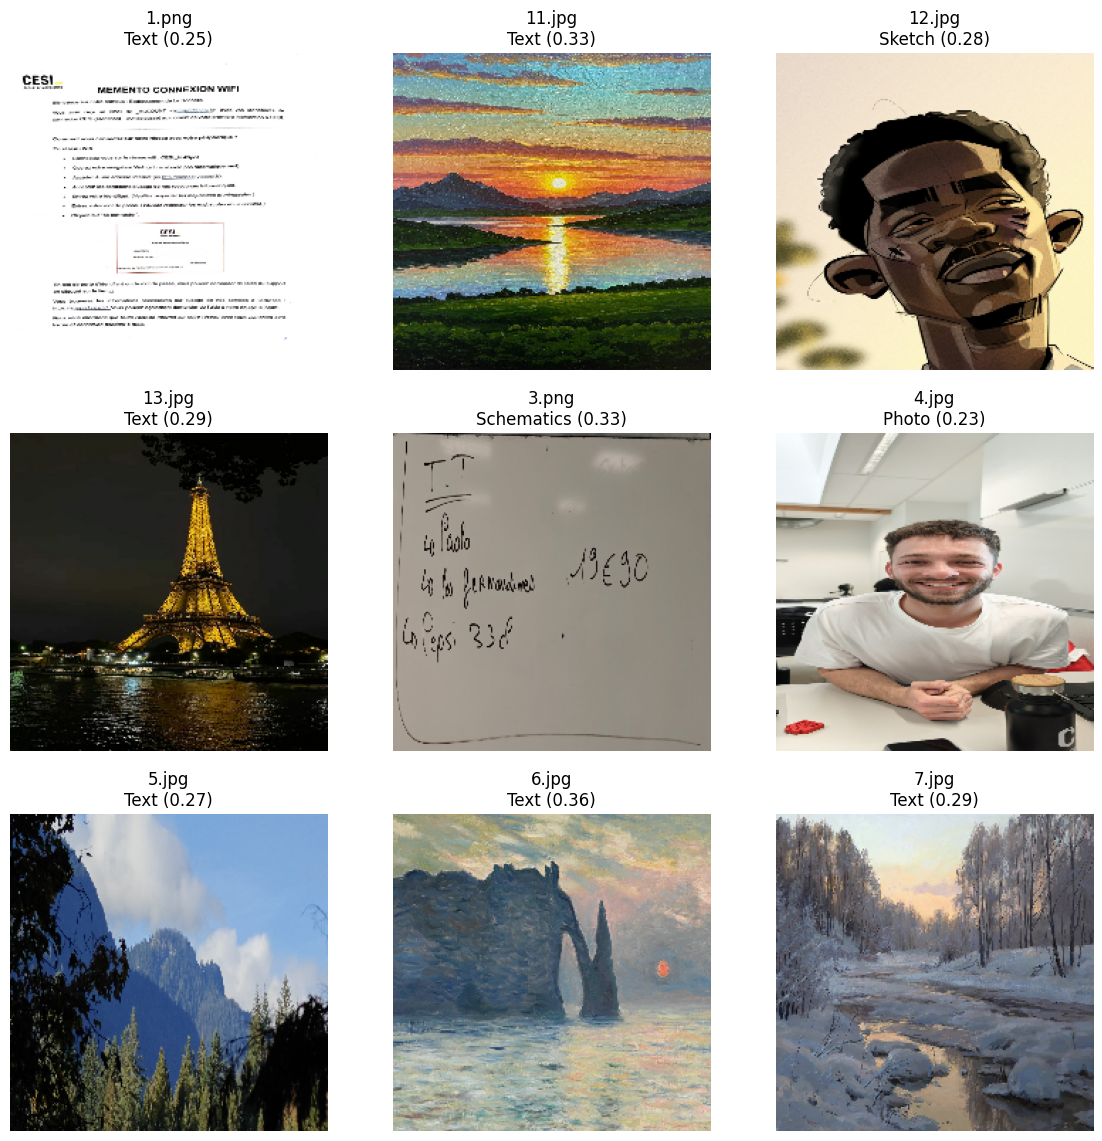

In [7]:
FINAL_DIR = pathlib.Path("../../datasets/final")
final_image_paths = sorted(
    [path for path in FINAL_DIR.glob("*.*") if path.suffix.lower() in {".jpg", ".jpeg", ".png"}]
)

print("Nombre d'images dans datasets/final :", len(final_image_paths))

final_raw_images = []
for image_path in final_image_paths:
    image_bytes = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH))
    final_raw_images.append(image)

final_raw_images = tf.stack(final_raw_images)
final_processed_images = preprocess_input(tf.cast(final_raw_images, tf.float32))
final_scores = model.predict(final_processed_images, verbose=0)
final_predicted_indices = tf.argmax(final_scores, axis=1)
final_confidences = tf.reduce_max(final_scores, axis=1)

print("Prédictions sur datasets/final :")
for index in range(len(final_image_paths)):
    print(
        f"- image: {final_image_paths[index].name} | "
        f"prédit: {class_names[int(final_predicted_indices[index])]} | "
        f"confiance: {float(final_confidences[index]):.3f}"
    )

plt.figure(figsize=(14, 14))
for index in range(min(9, len(final_image_paths))):
    ax = plt.subplot(3, 3, index + 1)
    plt.imshow(tf.cast(final_raw_images[index], tf.uint8))
    plt.title(
        f"{final_image_paths[index].name}\n"
        f"{class_names[int(final_predicted_indices[index])]} ({float(final_confidences[index]):.2f})"
    )
    plt.axis("off")